In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [2]:
brain = np.random.choice([-1, 1], size=40)
brainTest = brain.copy()
brain2 = brain.copy()

W = np.random.choice([-1, 0, 1], size=((40, 40)), p=[0.2, 0.6, 0.2])
W = np.triu(W, k=1)
W = W + W.T

T = 0.1
T2 = 10

def Es(brain,W):
  E = -0.5 * (brain @ W @ brain)
  return(E)

def Epr(brain, W, i):
    somme_voisins = W[i, :] @ brain
    dE = -2 * brain[i] * somme_voisins
    return dE

def Psi(Ei, T):
    ei = np.exp(-(Ei/T))
    g = 1/(1+ei)
    return g

def update_T(succes):
    if succes:
        T = 0.1
    else:
        T = 10
    return T

StockEs = []
StockEs2 = []
StockEs3 = []
StockEs4 = []
StockT = []
StockSucces = []
StockT1 = []
StockSucces1 = []

# 1.2 Function definitions and storage lists
I define here the functions needed for the model's structure (energy, delta-energy, sigmoid probability, temperature update), as well as the lists used to store values for plotting with matplotlib. I also initialize brain and W for the first test in 1.3.

[-2  0  0  0  0  0  0  2  0  0 -2 -2  0  0  0  2  0 -2  0  2  2  0  0  2
  0  2  2  2  0 -2  0  2  0  0 -2  0  2 -2  0  0]


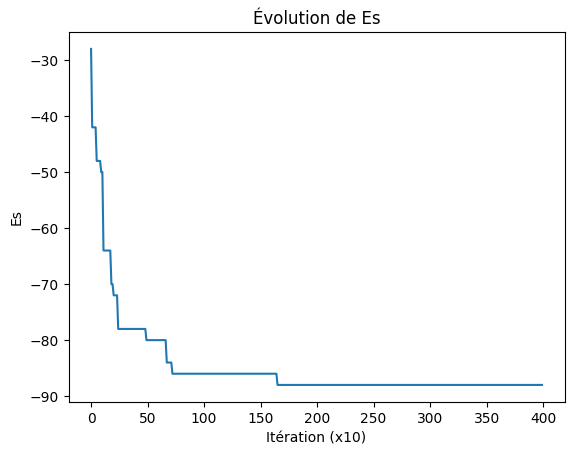

In [3]:
for cycle in range(10):
 for i in range(len(brain)):
  Energie = Es(brain, W)
  StockEs.append(Energie)
  Ei = Epr(brain, W, i)
  pi = Psi(Ei, T)
  tirage = np.random.rand()
  if tirage < pi:
    brain[i] *= -1


a = brain - brainTest
print(a)

plt.plot(StockEs)
plt.xlabel("Itération (x10)")
plt.ylabel("Es")
plt.title("Évolution de Es")
plt.show()

# 1.3 Test
I run a simple test to check whether the network converges, using a low temperature (T = 0.1). I compare the final brain state with the initial one (brainTest) to see how many neurons changed, and I plot the evolution of the energy Es over the iterations.

[ 0  0 -2  2  0  0  0  0  0 -2 -2 -2  0  0  0  0  0 -2  0  0  0 -2  2  2
  0  0  0  2 -2  0  2  2  0  2 -2  0  0  0  0  0]


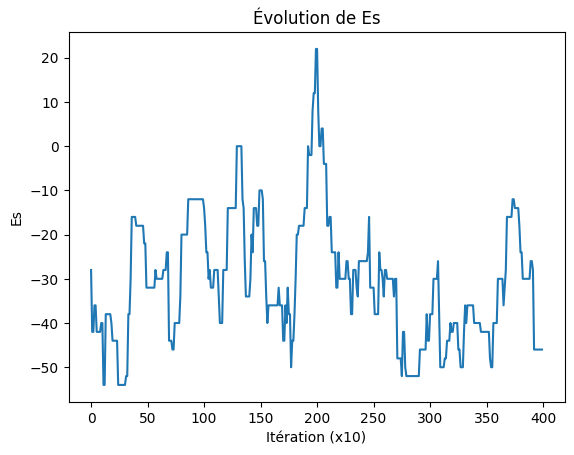

In [4]:
for cycle in range(10):
 for i in range(len(brain2)):
  Energie = Es(brain2, W)
  StockEs2.append(Energie)
  Ei = Epr(brain2, W, i)
  pi = Psi(Ei, T2)
  tirage = np.random.rand()
  if tirage < pi:
    brain2[i] *= -1


a = brain2 - brainTest
print(a)

plt.plot(StockEs2)
plt.xlabel("Itération (x10)")
plt.ylabel("Es")
plt.title("Évolution de Es")
plt.show()

# 1.4 Same test with a high temperature
Same experiment as in 1.3, but this time with T = 10 (high temperature). The energy no longer converges to a stable minimum: it keeps fluctuating, since the network is constantly and randomly pushed out of any state it reaches.

In [5]:
stockd = []
for j in range(200):
  d = np.random.choice([-1,1], size=8)
  e = np.random.choice([-1,1], size=8)
  m1 = np.mean(d)
  m2 = np.mean(e)
  z = abs(m1 - m2)
  if z == 0:
    stockd.append(z)
prct = len(stockd) / 200 * 100
print(prct)

17.5


# 1.5 Baseline chance test
Here I check, for two random 8-neuron zones, how likely it is that they already match by pure chance (without any learning). This gives a baseline to later verify that any apparent "success" in the full model (1.6) is really due to learning and not just luck.

/tmp/ipykernel_15509/238435438.py:22: RuntimeWarning: overflow encountered in exp
  ei = np.exp(-(Ei/T))


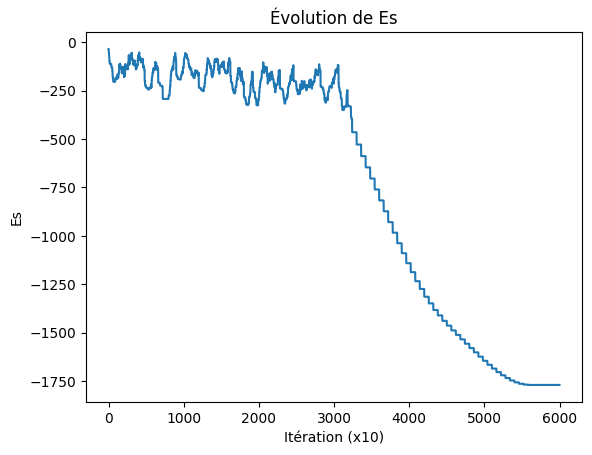

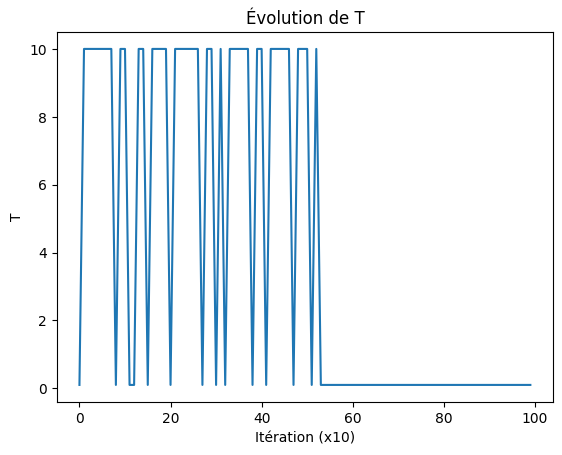

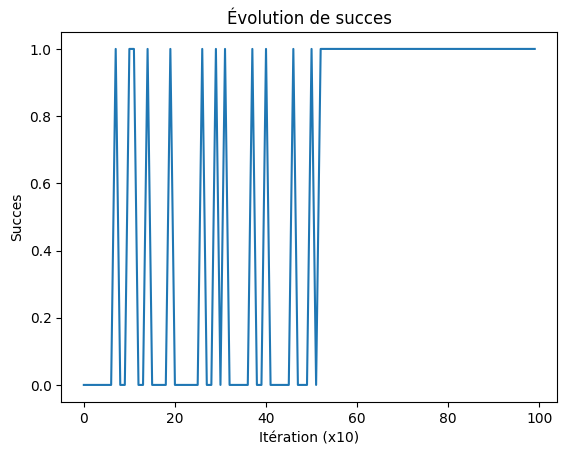

In [6]:
brain3 = np.random.choice([-1, 1], size=60)

Ww = np.random.choice([-1, 0, 1], size=((60, 60)), p=[0.3, 0.4, 0.3])
Ww = np.triu(Ww, k=1)
Ww = Ww + Ww.T
Ww = Ww.astype(float)

Tt = 0.1
eta = 0.05

for cycle in range(100):
 for i in range(len(brain3)):
  Energie = Es(brain3, Ww)
  StockEs3.append(Energie)
  Ei = Epr(brain3, Ww, i)
  pi = Psi(Ei, Tt)
  tirage = np.random.rand()
  if tirage < pi:
    brain3[i] *= -1

 StockT.append(Tt)
 zone1 = brain3[1:9]
 zone2 = brain3[9:17]
 moy1 = np.mean(zone1)
 moy2 = np.mean(zone2)
 ecart = abs(moy1 - moy2)
 a = ecart == 0
 StockSucces.append(a)
 Tt = update_T(a)

 if a:
    delta_W = eta * np.outer(brain3, brain3)
    np.fill_diagonal(delta_W, 0)
    Ww += delta_W
    Ww = np.clip(Ww, -1, 1)

plt.plot(StockEs3)
plt.xlabel("Itération (x10)")
plt.ylabel("Es")
plt.title("Évolution de Es")
plt.show()

plt.plot(StockT)
plt.xlabel("Itération (x10)")
plt.ylabel("T")
plt.title("Évolution de T")
plt.show()

plt.plot(StockSucces)
plt.xlabel("Itération (x10)")
plt.ylabel("Succes")
plt.title("Évolution de succes")
plt.show()

# 1.6 Full model: learning loop
Here I finally run the complete model (dynamics + success condition + Hebbian learning with clipping) to see whether it learns. We can see that it does learn quite well, although the task is still a simple/basic one. In 1.5, I checked that this success rate isn't just due to chance.

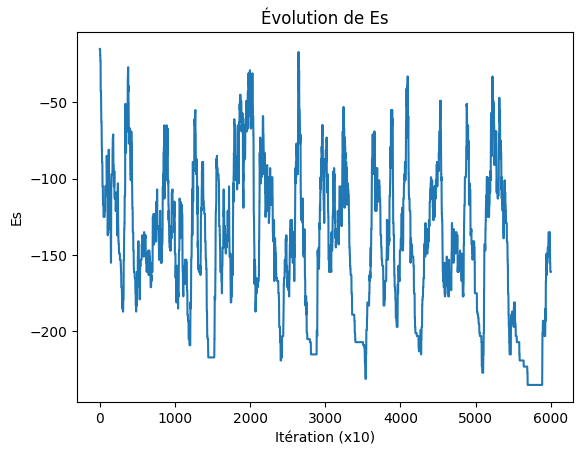

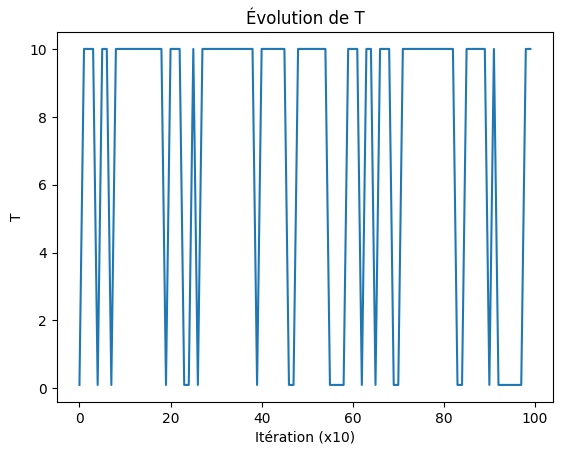

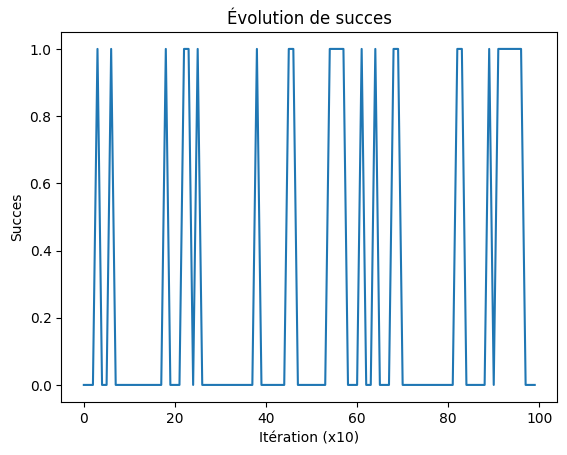

In [7]:
brain4 = np.random.choice([-1, 1], size=60)

Ww1 = np.random.choice([-1, 0, 1], size=((60, 60)), p=[0.3, 0.4, 0.3])
Ww1 = np.triu(Ww1, k=1)
Ww1 = Ww1 + Ww1.T
Ww1 = Ww1.astype(float)

Tt1 = 0.1
eta1 = 0.05

for cycle in range(100):
 for i in range(len(brain4)):
  Energie = Es(brain4, Ww1)
  StockEs4.append(Energie)
  Ei = Epr(brain4, Ww1, i)
  pi = Psi(Ei, Tt1)
  tirage = np.random.rand()
  if tirage < pi:
    brain4[i] *= -1

 StockT1.append(Tt1)
 zone1 = brain4[1:9]
 zone2 = brain4[9:17]
 moy1 = np.mean(zone1)
 moy2 = np.mean(zone2)
 ecart = abs(moy1 - moy2)
 a = ecart == 0
 StockSucces1.append(a)
 Tt1 = update_T(a)


plt.plot(StockEs4)
plt.xlabel("Itération (x10)")
plt.ylabel("Es")
plt.title("Évolution de Es")
plt.show()

plt.plot(StockT1)
plt.xlabel("Itération (x10)")
plt.ylabel("T")
plt.title("Évolution de T")
plt.show()

plt.plot(StockSucces1)
plt.xlabel("Itération (x10)")
plt.ylabel("Succes")
plt.title("Évolution de succes")
plt.show()

#1.7 Final Test
Here the final test to be sure that is not luck : I delete the w update to see if the model can perform without. We can see that he can't learn so it's confirm that the dishbrain on 1.6 it's real neural network.